In [1]:
import pandas as pd
import numpy as np
import os
import requests
JAN_START = '2024-01-01'
JAN_END = '2024-01-31'
ACTUALS_CSV = 'actuals_jan2024.csv'
FORECASTS_CSV = 'forecasts_jan2024.csv'
# Elexon direct endpoints:
ACTUALS_URL = f'https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH/stream?publishDateTimeFrom={JAN_START}T00:00:00Z&publishDateTimeTo={JAN_END}T23:59:59Z&fuelType=WIND'
FORECASTS_URL = f'https://data.elexon.co.uk/bmrs/api/v1/datasets/WINDFOR/stream?publishDateTimeFrom={JAN_START}&publishDateTimeTo={JAN_END}'
if os.path.exists(ACTUALS_CSV):
    actuals = pd.read_csv(ACTUALS_CSV, parse_dates=['startTime'])
else:
    ac_raw = requests.get(ACTUALS_URL).json()
    actuals = pd.DataFrame(ac_raw)
    actuals['startTime'] = pd.to_datetime(actuals['startTime'])
    actuals.to_csv(ACTUALS_CSV, index=False)
    print('Downloaded and cached actuals.')
if os.path.exists(FORECASTS_CSV):
    forecasts = pd.read_csv(FORECASTS_CSV, parse_dates=['startTime', 'publishTime'])
else:
    fc_raw = requests.get(FORECASTS_URL).json()
    forecasts = pd.DataFrame(fc_raw)
    forecasts['startTime'] = pd.to_datetime(forecasts['startTime'])
    forecasts['publishTime'] = pd.to_datetime(forecasts['publishTime'])
    forecasts.to_csv(FORECASTS_CSV, index=False)
    print('Downloaded and cached forecasts.')
print(f'Loaded {len(actuals)} actuals and {len(forecasts)} forecasts.')

Downloaded and cached actuals.
Downloaded and cached forecasts.
Loaded 1488 actuals and 11760 forecasts.


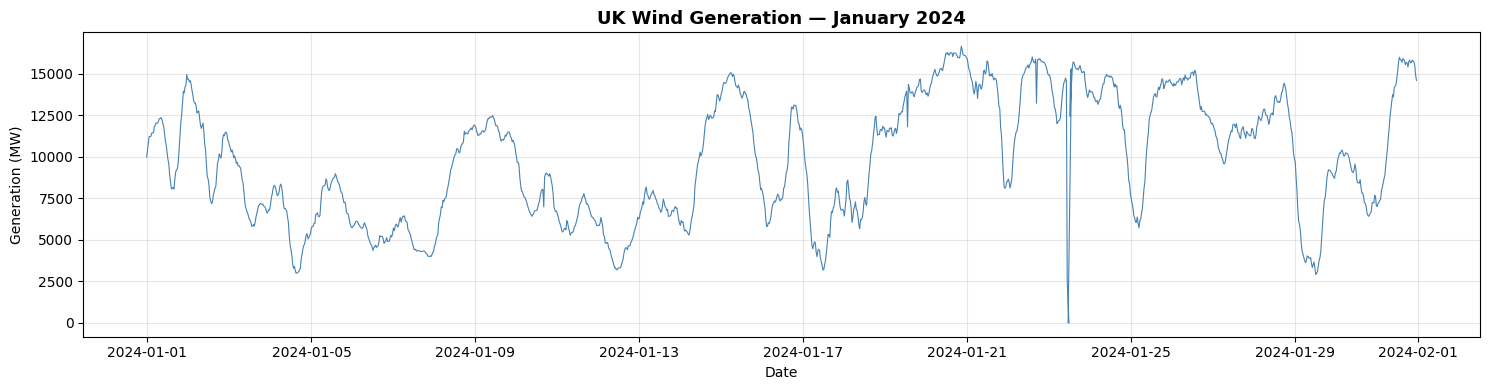

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 4))
plt.plot(actuals['startTime'], actuals['generation'], color='steelblue', linewidth=0.8)
plt.title('UK Wind Generation — January 2024', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Generation (MW)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_raw_generation.png', dpi=150)
plt.show()

In [4]:
percentiles = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
values = {f"P{int(p*100)}": actuals['generation'].quantile(p) for p in percentiles}

print("=" * 50)
print("      WIND GENERATION PERCENTILE TABLE")
print("=" * 50)
print(f"{'Percentile':<12} {'MW Value':>10}  {'Reliability'}")
print("-" * 50)
for label, val in values.items():
    pct = int(label[1:])
    reliability = 100 - pct
    print(f"{label:<12} {val:>10.0f} MW  → available {reliability}% of time")

print("=" * 50)
print(f"\nMean generation: {actuals['generation'].mean():.0f} MW")
print(f"Min  generation: {actuals['generation'].min():.0f} MW")
print(f"Max  generation: {actuals['generation'].max():.0f} MW")

      WIND GENERATION PERCENTILE TABLE
Percentile     MW Value  Reliability
--------------------------------------------------
P5                 4301 MW  → available 95% of time
P10                5088 MW  → available 90% of time
P25                6732 MW  → available 75% of time
P50                9864 MW  → available 50% of time
P75               13099 MW  → available 25% of time
P90               14810 MW  → available 10% of time
P95               15425 MW  → available 5% of time

Mean generation: 9846 MW
Min  generation: 0 MW
Max  generation: 16662 MW


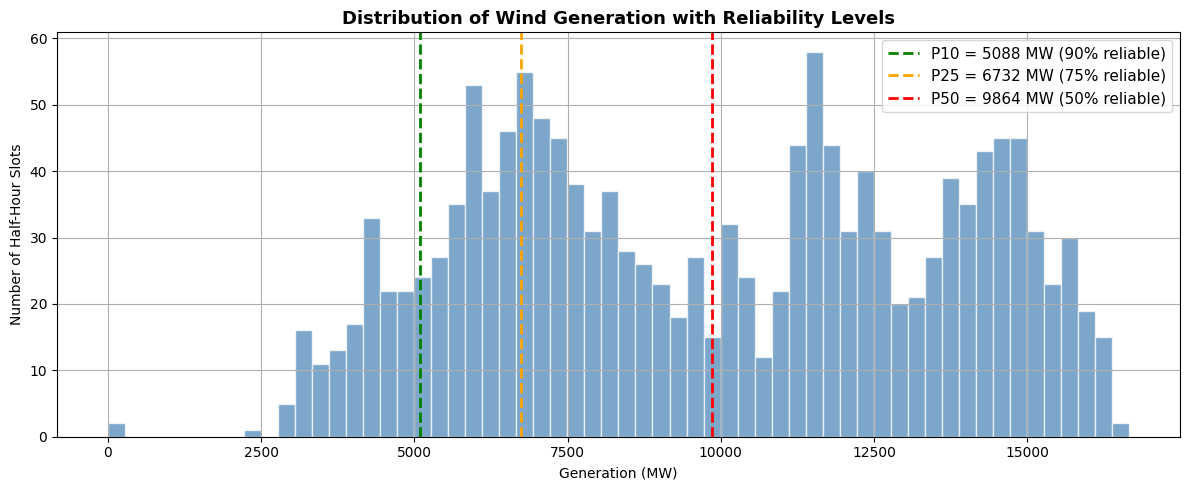

In [5]:
p10 = actuals['generation'].quantile(0.10)
p25 = actuals['generation'].quantile(0.25)
p50 = actuals['generation'].quantile(0.50)

plt.figure(figsize=(12, 5))
actuals['generation'].hist(bins=60, color='steelblue', edgecolor='white', alpha=0.7)
plt.axvline(p10, color='green',  linestyle='--', linewidth=2, label=f'P10 = {p10:.0f} MW (90% reliable)')
plt.axvline(p25, color='orange', linestyle='--', linewidth=2, label=f'P25 = {p25:.0f} MW (75% reliable)')
plt.axvline(p50, color='red',    linestyle='--', linewidth=2, label=f'P50 = {p50:.0f} MW (50% reliable)')
plt.title('Distribution of Wind Generation with Reliability Levels', fontsize=13, fontweight='bold')
plt.xlabel('Generation (MW)')
plt.ylabel('Number of Half-Hour Slots')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('plot_generation_distribution.png', dpi=150)
plt.show()

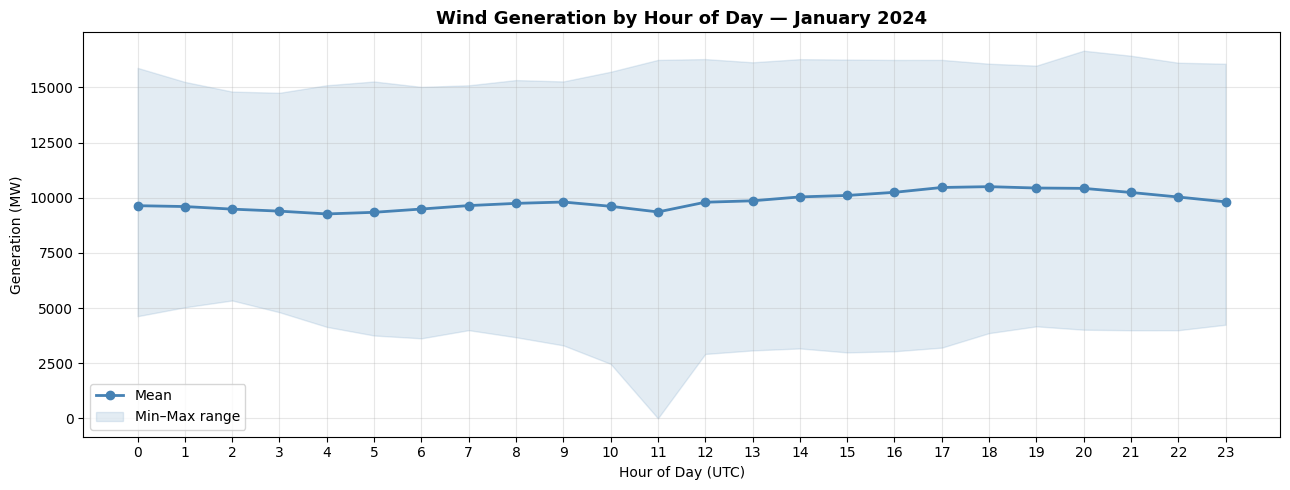

In [6]:
actuals['hour'] = actuals['startTime'].dt.hour
hourly = actuals.groupby('hour')['generation'].agg(['mean', 'min', 'max'])

plt.figure(figsize=(13, 5))
plt.plot(hourly.index, hourly['mean'], marker='o', color='steelblue', linewidth=2, label='Mean')
plt.fill_between(hourly.index, hourly['min'], hourly['max'], alpha=0.15, color='steelblue', label='Min–Max range')
plt.title('Wind Generation by Hour of Day — January 2024', fontsize=13, fontweight='bold')
plt.xlabel('Hour of Day (UTC)')
plt.ylabel('Generation (MW)')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_generation_by_hour.png', dpi=150)
plt.show()

In [7]:
thresholds = [1000, 2000, 3000, 4000, 5000]

print("=" * 45)
print("  RISK TABLE — Low Generation Events")
print("=" * 45)
for t in thresholds:
    count = (actuals['generation'] < t).sum()
    pct   = count / len(actuals) * 100
    print(f"Below {t:,} MW → {count} slots ({pct:.1f}% of January)")
print("=" * 45)

  RISK TABLE — Low Generation Events
Below 1,000 MW → 2 slots (0.1% of January)
Below 2,000 MW → 2 slots (0.1% of January)
Below 3,000 MW → 5 slots (0.3% of January)
Below 4,000 MW → 57 slots (3.8% of January)
Below 5,000 MW → 142 slots (9.5% of January)


## 📋 Notebook 2 — Reliable Wind Capacity Recommendation

### What the data shows
- January 2024 wind generation ranged from **0 MW** to **16,662 MW**
- Average (mean) generation was **9,846 MW**
- Generation is highly volatile — dropped as low as **0 MW** at times

### Percentile Summary
| Reliability Level       | MW Available |
|-------------------------|-------------|
| 90% of the time (P10)   | 5,088 MW    |
| 75% of the time (P25)   | 6,732 MW    |
| 50% of the time (P50)   | 9,864 MW    |

### ✅ Recommendation
**Plan around 5,088 MW (P10 level) as the reliable wind baseline.**

**Reasoning:**
1. The P10 value means wind exceeded this level 90% of the time in January 2024
2. This is the standard "P90 reliability" threshold used in energy grid planning
3. Using the mean (9,846 MW) would be too optimistic — wind regularly falls below average
4. The min value of 0 MW shows wind can drop very low — never rely on wind alone

### ⚠️ Caveats
- January is one month only — UK winter wind is typically stronger than summer
- A full year of data would give a more reliable recommendation
- Wind should always be paired with backup capacity (gas peakers, battery storage) for the remaining 10% of time when generation falls below the P10 level